In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("diabetes_patients.csv")
df.head()

,Patient_ID,Age,Gender,Blood_Sugar_Level,Creatinine,BMI,Urea,Cholesterol,HbA1c,Class
0,1.0,60.0,Male,96.0,1.34,22.5,23.0,176.0,8.6,Diabetic
1,2.0,77.0,Male,241.0,1.02,19.0,28.0,209.0,7.5,Diabetic
2,3.0,21.0,Male,229.0,1.02,25.9,32.0,151.0,9.1,Diabetic
3,4.0,30.0,Female,177.0,0.88,22.1,36.0,176.0,5.1,Diabetic
4,5.0,26.0,Female,178.0,1.20,31.8,44.0,287.0,5.2,Diabetic


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         9689 non-null   float64
 1   Age                9675 non-null   float64
 2   Gender             9530 non-null   object 
 3   Blood_Sugar_Level  9535 non-null   float64
 4   Creatinine         9749 non-null   float64
 5   BMI                9749 non-null   float64
 6   Urea               9740 non-null   float64
 7   Cholesterol        9937 non-null   float64
 8   HbA1c              9986 non-null   float64
 9   Class              9985 non-null   object 
dtypes: float64(8), object(2)
memory usage: 781.4+ KB


In [4]:
df.describe()

,Patient_ID,Age,Blood_Sugar_Level,Creatinine,BMI,Urea,Cholesterol,HbA1c
count,9689.000000,9675.000000,9535.000000,9749.000000,9749.000000,9740.000000,9937.000000,9986.000000
mean,5030.696150,49.971266,169.185632,1.100609,26.746805,35.126591,225.351112,7.503875
std,2920.589701,17.627406,46.055875,0.287080,4.787478,11.818323,43.796330,1.743940
min,1.000000,20.000000,90.000000,0.600000,18.500000,15.000000,150.000000,4.500000
25%,2423.000000,35.000000,130.000000,0.850000,22.600000,25.000000,187.000000,6.000000
50%,5140.000000,50.000000,169.000000,1.100000,26.700000,35.000000,225.000000,7.500000
75%,7562.000000,65.000000,209.000000,1.350000,31.000000,45.000000,263.000000,9.000000
max,10000.000000,80.000000,250.000000,1.600000,35.000000,55.000000,300.000000,10.500000


In [5]:
df.describe(include="O")

,Gender,Class
count,9530,9985
unique,2,2
top,Female,Diabetic
freq,4796,9131


In [3]:
df.isnull().sum()

,0
Patient_ID,311
Age,325
Gender,470
Blood_Sugar_Level,465
Creatinine,251
BMI,251
Urea,260
Cholesterol,63
HbA1c,14
Class,15


In [4]:
df.duplicated().sum()

np.int64(9)

In [5]:
df["Class"].value_counts()

,count
Class,
Diabetic,9131
Non-Diabetic,854


In [6]:
df_clean = df.copy()

In [7]:
df_clean.isnull().sum() / len(df_clean) * 100

,0
Patient_ID,3.11
Age,3.25
Gender,4.70
Blood_Sugar_Level,4.65
Creatinine,2.51
BMI,2.51
Urea,2.60
Cholesterol,0.63
HbA1c,0.14
Class,0.15


In [8]:
numeric_columns = [
    "Patient_ID",
    "Age",
    "Blood_Sugar_Level",
    "Creatinine",
    "BMI",
    "Urea",
    "Cholesterol",
    "HbA1c"
]

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [9]:
df_clean["Gender"] = df_clean["Gender"].fillna(
    df_clean["Gender"].mode()[0]
)

In [10]:
df_clean["Class"] = df_clean["Class"].fillna(
    df_clean["Class"].mode()[0]
)

In [11]:
df_clean.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Blood_Sugar_Level,0
Creatinine,0
BMI,0
Urea,0
Cholesterol,0
HbA1c,0
Class,0


In [12]:
df_clean = df_clean.drop_duplicates()

In [13]:
df_clean.duplicated().sum()

np.int64(0)

In [14]:
df_clean.dtypes

,0
Patient_ID,float64
Age,float64
Gender,object
Blood_Sugar_Level,float64
Creatinine,float64
BMI,float64
Urea,float64
Cholesterol,float64
HbA1c,float64
Class,object


In [15]:
df_clean["Age"] = df_clean["Age"].astype(int)

In [16]:
df_clean["Gender"].value_counts()

,count
Gender,
Female,5257
Male,4734


In [17]:
df_clean["Class"].unique()

array(['Diabetic', 'Non-Diabetic'], dtype=object)

In [18]:
df_clean["Class"].value_counts()

,count
Class,
Diabetic,9138
Non-Diabetic,853


In [19]:
X = df_clean.drop(["Class", "Patient_ID"], axis=1)
y = df_clean["Class"]

In [21]:
df_clean.shape

(9991, 10)

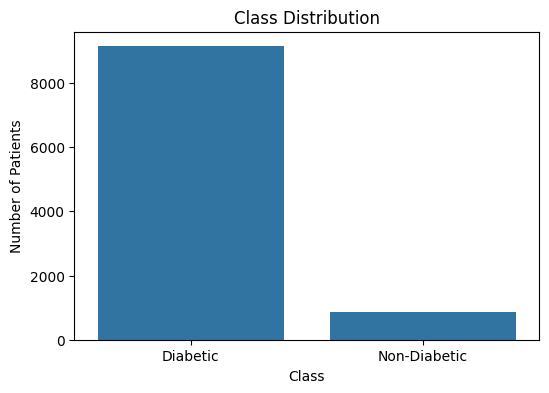

In [22]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df_clean, x="Class")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

plt.show()

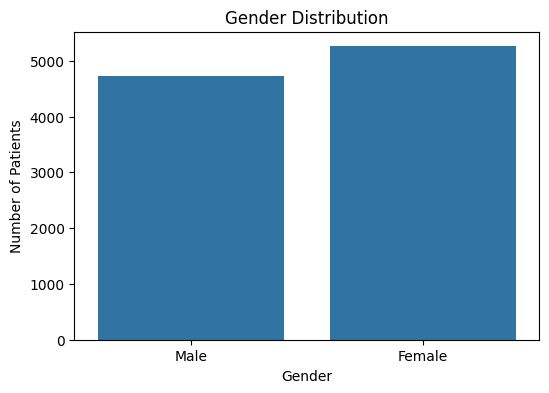

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df_clean, x="Gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

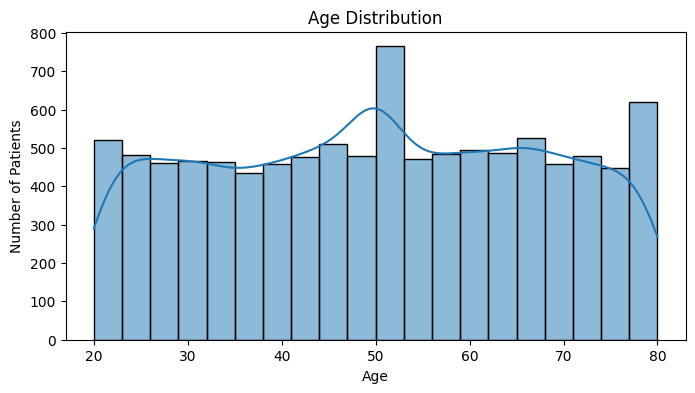

In [24]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df_clean, x="Age", bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

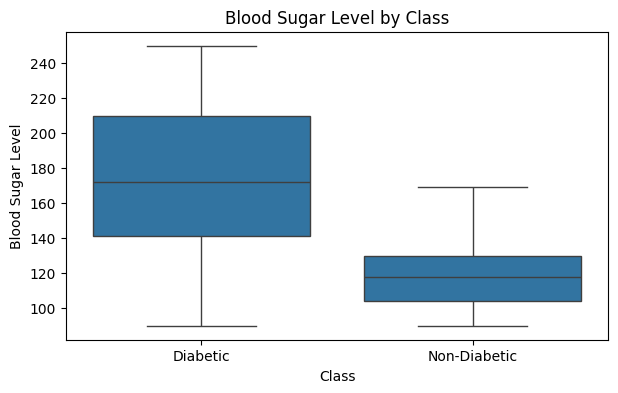

In [25]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df_clean, x="Class", y="Blood_Sugar_Level")

plt.title("Blood Sugar Level by Class")
plt.xlabel("Class")
plt.ylabel("Blood Sugar Level")

plt.show()

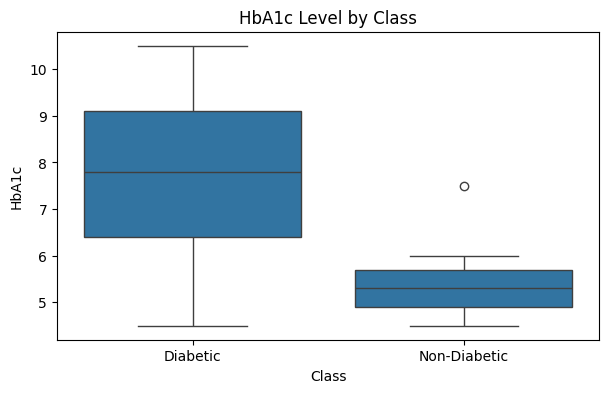

In [26]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df_clean, x="Class", y="HbA1c")

plt.title("HbA1c Level by Class")
plt.xlabel("Class")
plt.ylabel("HbA1c")

plt.show()

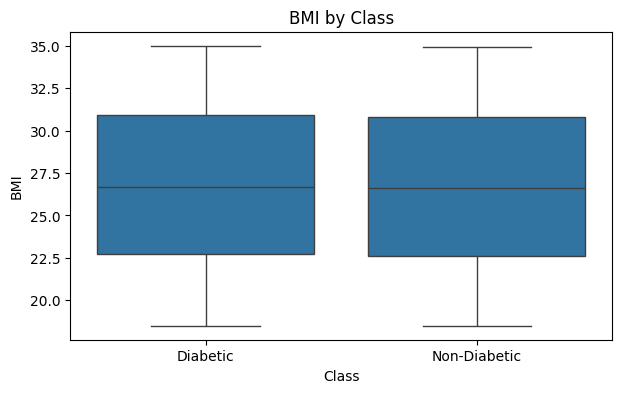

In [27]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df_clean, x="Class", y="BMI")

plt.title("BMI by Class")
plt.xlabel("Class")
plt.ylabel("BMI")

plt.show()

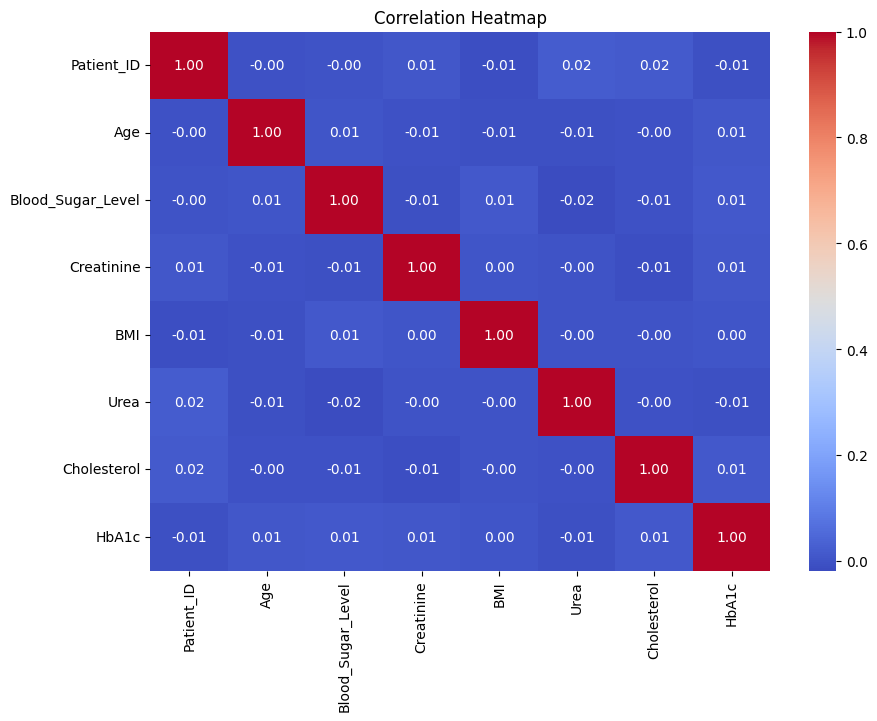

In [28]:
plt.figure(figsize=(10, 7))

correlation = df_clean.select_dtypes(
    include="number"
).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [29]:
X = df_clean.drop(["Class", "Patient_ID"], axis=1)

y = df_clean["Class"]

In [30]:
X.head()

,Age,Gender,Blood_Sugar_Level,Creatinine,BMI,Urea,Cholesterol,HbA1c
0,60,Male,96.0,1.34,22.5,23.0,176.0,8.6
1,77,Male,241.0,1.02,19.0,28.0,209.0,7.5
2,21,Male,229.0,1.02,25.9,32.0,151.0,9.1
3,30,Female,177.0,0.88,22.1,36.0,176.0,5.1
4,26,Female,178.0,1.20,31.8,44.0,287.0,5.2


In [31]:
y.head()

,Class
0,Diabetic
1,Diabetic
2,Diabetic
3,Diabetic
4,Diabetic


In [32]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()

X["Gender"] = gender_encoder.fit_transform(X["Gender"])

In [33]:
X.head()

,Age,Gender,Blood_Sugar_Level,Creatinine,BMI,Urea,Cholesterol,HbA1c
0,60,1,96.0,1.34,22.5,23.0,176.0,8.6
1,77,1,241.0,1.02,19.0,28.0,209.0,7.5
2,21,1,229.0,1.02,25.9,32.0,151.0,9.1
3,30,0,177.0,0.88,22.1,36.0,176.0,5.1
4,26,0,178.0,1.20,31.8,44.0,287.0,5.2


In [34]:
class_encoder = LabelEncoder()

y = class_encoder.fit_transform(y)

In [35]:
np.unique(y)

array([0, 1])

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (7992, 8)
X_test : (1999, 8)
y_train: (7992,)
y_test : (1999,)


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [39]:
X_train[:5]

array([[ 0.69598041, -0.95138065, -0.2700488 ,  1.4743672 , -1.15254927,
         0.68158872, -1.04011752,  0.45569417],
       [-1.49557203,  1.05110399,  0.39796841, -0.74031761, -0.03094387,
         0.51009179,  0.12668469,  1.54704878],
       [-0.05376121, -0.95138065,  1.75627008,  1.19313739, -0.60232775,
        -0.86188366, -0.01058616, -1.26749732],
       [ 1.04201501, -0.95138065,  1.73400284, -1.09185489, -1.36417293,
         0.42434332, -1.13163141,  0.51313388],
       [ 0.00391122, -0.95138065, -0.00284192, -0.77547134, -0.56000302,
        -1.46212292,  0.26395553, -1.15261789]])

In [41]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)

LogisticRegression()

In [42]:
y_pred_logistic = logistic_model.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall   :", recall_logistic)
print("F1-Score :", f1_logistic)

Logistic Regression
-------------------
Accuracy : 0.9749874937468734
Precision: 0.9172413793103448
Recall   : 0.7777777777777778
F1-Score : 0.8417721518987342


In [44]:
print(f"Accuracy : {accuracy_logistic * 100:.2f}%")
print(f"Precision: {precision_logistic * 100:.2f}%")
print(f"Recall   : {recall_logistic * 100:.2f}%")
print(f"F1-Score : {f1_logistic * 100:.2f}%")

Accuracy : 97.50%
Precision: 91.72%
Recall   : 77.78%
F1-Score : 84.18%


In [45]:
from sklearn.metrics import confusion_matrix

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print(cm_logistic)

[[1816   12]
 [  38  133]]


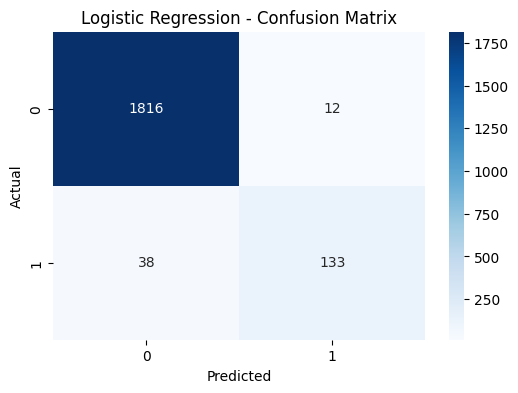

In [46]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1828
           1       0.92      0.78      0.84       171

    accuracy                           0.97      1999
   macro avg       0.95      0.89      0.91      1999
weighted avg       0.97      0.97      0.97      1999



In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn_params = {
    "n_neighbors": range(1, 21)
}
knn_grid = GridSearchCV(
    knn,
    knn_params,
    cv=5,
    scoring="f1"
)

knn_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 21)}, scoring='f1')

In [52]:
print("Best K:", knn_grid.best_params_)
print("Best F1-Score:", knn_grid.best_score_)

Best K: {'n_neighbors': 7}
Best F1-Score: 0.7229636575839825


In [53]:
best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(X_test)

In [54]:
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1-Score :", f1_score(y_test, y_pred_knn))

Accuracy : 0.9569784892446224
Precision: 0.8195488721804511
Recall   : 0.6374269005847953
F1-Score : 0.7171052631578947


In [55]:
from sklearn.svm import SVC

In [56]:
svm = SVC()
svm_params = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}
svm_grid = GridSearchCV(
    svm,
    svm_params,
    cv=5,
    scoring="f1"
)

svm_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='f1')

In [57]:
print("Best Parameters:", svm_grid.best_params_)
print("Best F1-Score:", svm_grid.best_score_)

Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best F1-Score: 0.87461419109574


In [58]:
best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test)

In [59]:
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1-Score :", f1_score(y_test, y_pred_svm))

Accuracy : 0.9769884942471235
Precision: 0.8834355828220859
Recall   : 0.8421052631578947
F1-Score : 0.8622754491017964


In [60]:
knn_results = pd.DataFrame(knn_grid.cv_results_)

knn_results[
    ["param_n_neighbors", "mean_test_score"]
].sort_values(
    "mean_test_score",
    ascending=False
).head(10)

,param_n_neighbors,mean_test_score
6,7,0.722964
8,9,0.715775
2,3,0.715001
4,5,0.714906
10,11,0.713561
0,1,0.699608
12,13,0.691281
14,15,0.670663
7,8,0.667098
5,6,0.662818


In [61]:
svm_results = pd.DataFrame(svm_grid.cv_results_)

svm_results[
    [
        "param_C",
        "param_kernel",
        "param_gamma",
        "mean_test_score"
    ]
].sort_values(
    "mean_test_score",
    ascending=False
).head(10)

,param_C,param_kernel,param_gamma,mean_test_score
13,100.0,rbf,scale,0.874614
15,100.0,rbf,auto,0.874614
11,10.0,rbf,auto,0.874404
9,10.0,rbf,scale,0.874404
7,1.0,rbf,auto,0.838079
5,1.0,rbf,scale,0.838079
8,10.0,linear,scale,0.805763
10,10.0,linear,auto,0.805763
12,100.0,linear,scale,0.803665
14,100.0,linear,auto,0.803665


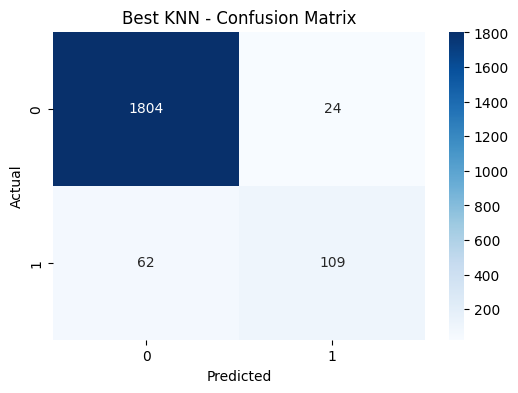

In [62]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Best KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

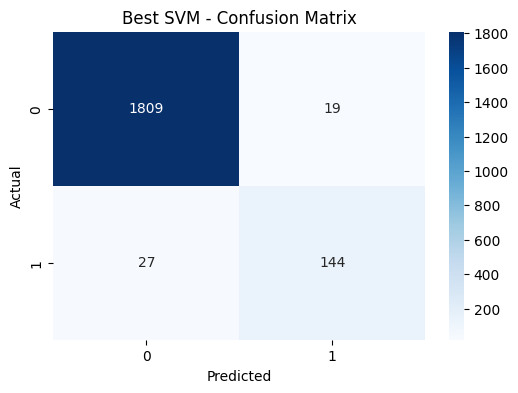

In [63]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Best SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [64]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision": [
        precision_logistic,
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svm)
    ],
    "Recall": [
        recall_logistic,
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svm)
    ],
    "F1-Score": [
        f1_logistic,
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svm)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.974987,0.917241,0.777778,0.841772
1,KNN,0.956978,0.819549,0.637427,0.717105
2,SVM,0.976988,0.883436,0.842105,0.862275


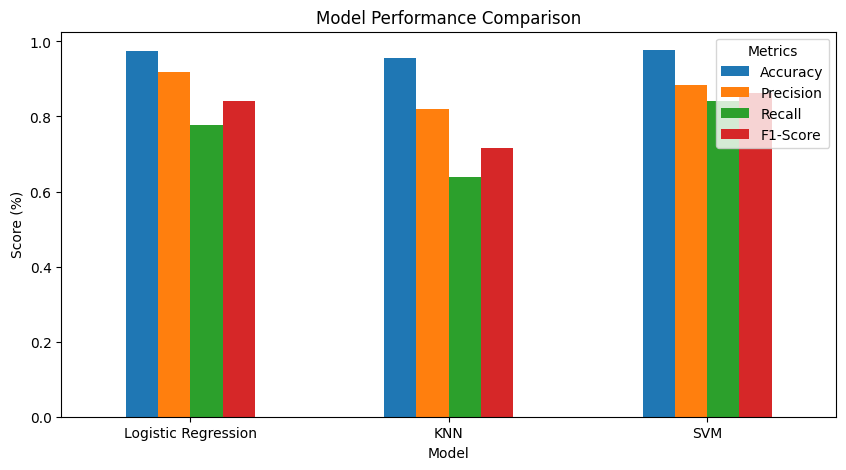

In [65]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score (%)")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(title="Metrics")

plt.show()

In [66]:
best_model_name = results.loc[
    results["F1-Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: SVM


In [67]:
best_model = best_svm

print("Final Model: SVM")
print("Best Parameters:", svm_grid.best_params_)

Final Model: SVM
Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


In [68]:
final_accuracy = accuracy_score(y_test, y_pred_svm)
final_precision = precision_score(y_test, y_pred_svm)
final_recall = recall_score(y_test, y_pred_svm)
final_f1 = f1_score(y_test, y_pred_svm)

print("Final SVM Performance")
print("---------------------")
print(f"Accuracy : {final_accuracy * 100:.2f}%")
print(f"Precision: {final_precision * 100:.2f}%")
print(f"Recall   : {final_recall * 100:.2f}%")
print(f"F1-Score : {final_f1 * 100:.2f}%")

Final SVM Performance
---------------------
Accuracy : 97.70%
Precision: 88.34%
Recall   : 84.21%
F1-Score : 86.23%


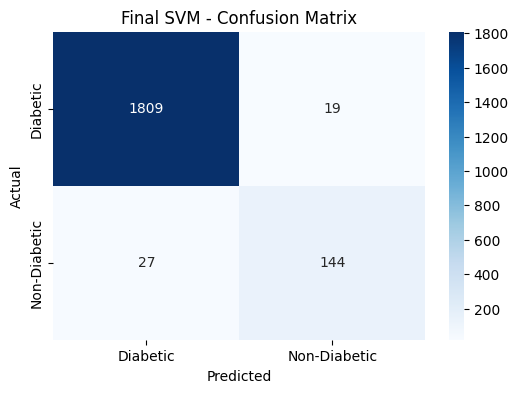

In [69]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_encoder.classes_,
    yticklabels=class_encoder.classes_
)

plt.title("Final SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [70]:
import joblib

model_data = {
    "model": best_svm,
    "scaler": scaler,
    "gender_encoder": gender_encoder,
    "class_encoder": class_encoder
}

joblib.dump(model_data, "diabetes_model.pkl")

['diabetes_model.pkl']

In [72]:
loaded_data = joblib.load("diabetes_model.pkl")

In [73]:
loaded_model = loaded_data["model"]
loaded_scaler = loaded_data["scaler"]
loaded_gender_encoder = loaded_data["gender_encoder"]
loaded_class_encoder = loaded_data["class_encoder"]

In [74]:
test_prediction = loaded_model.predict(X_test[:5])

print(test_prediction)

[0 0 0 0 0]


In [75]:
print(
    loaded_class_encoder.inverse_transform(test_prediction)
)

['Diabetic' 'Diabetic' 'Diabetic' 'Diabetic' 'Diabetic']
